In [1]:
%load_ext autoreload
%autoreload 2
# %matplotlib ipympl

In [2]:
import mesa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.animation import FuncAnimation
from abm.model import SocialGPModel
from abm.rewards import make_mexican_hat_reward, make_parent_and_children_correlated_dog
from abm.utils import plot_reward_grid, plot_most_common_choice_trajectory, animate_heatmap_trajectory, sample_parameters_from_csv
from abm.batch_analysis import (
    run_condition_batches,
    run_sampled_batches,
    summarize_condition_timeseries,
    summarize_mean_reward_last_steps,
    plot_condition_comparison,
    summarize_batch_metrics,
    plot_metric_suite_by_lambda,
 )

sns.set_theme(style="whitegrid")

# Single agent simulations
This notebook shows simulations done to establish the behavior of single agents in Mexican hat environments, sampling parameters from empirical distributions for each iteration

## 1. Naito 2022

### 2.a Simulate average behavior

In [15]:
grid_size   = 33
lambda_true = 4.5

# Original environment lambda parameters (from previous experiments)
naito_lambda_source = 1.5  
giron_lambda_source = 0.43

# Define reward parameters for the correlated dog environment
reward_params = {
    'length_scale': lambda_true,
    'sigma_outer': lambda_true,
    'sigma_inner': lambda_true/2.0,
}

### Sample parameters from Naito 2022 dataset

Run batch simulations where parameters (length_scale, tau, beta) are sampled from the empirical distributions in naito2022.csv. Each run samples a new parameter set from the dataset.

In [18]:
# Base parameters - parameters not in param_columns will use these fixed values
base_params = {
    "n": 1,
    "grid_size": grid_size,
    "alpha": 0,  # Fixed value (not in dataset)
    "reward_env_type": 'mexican_hat_2_valleys',
    "reward_env_params": [reward_params],
    "agent_reporters_to_collect": ["reward", "global_max", "local_max", "no_max", "cumulative_reward"],
}

# Mapping from model parameter names to CSV column names
param_columns = {
    'length_scale': 'lambda_0',
    'tau': 'tau_0',
    'beta': 'beta_0',
}

# Scaling: Naito parameters were fit for lambda_true=1.5, scale to our lambda_true=4.5
# Formula: scaled_value = sample * target_lambda / source_lambda
param_scaling = {
    'length_scale': (naito_lambda_source, lambda_true),
}

# Run batch with sampled parameters
n_runs    = 50  # Number of runs (will sample n_runs parameter sets from CSV)
max_steps = 30
rng       = np.random.default_rng(42)

sampled_df = run_sampled_batches(
    model_cls=SocialGPModel,
    base_parameters=base_params,
    csv_path='datasets/naito2022.csv',
    param_columns=param_columns,
    param_scaling=param_scaling,
    n_runs=n_runs,
    max_steps=max_steps,
    data_collection_period=1,
    display_progress=True,
    condition_name='naito_sampled',
    rng=rng,
)

ValueError: operands could not be broadcast together with shapes (2,) (33,33) 

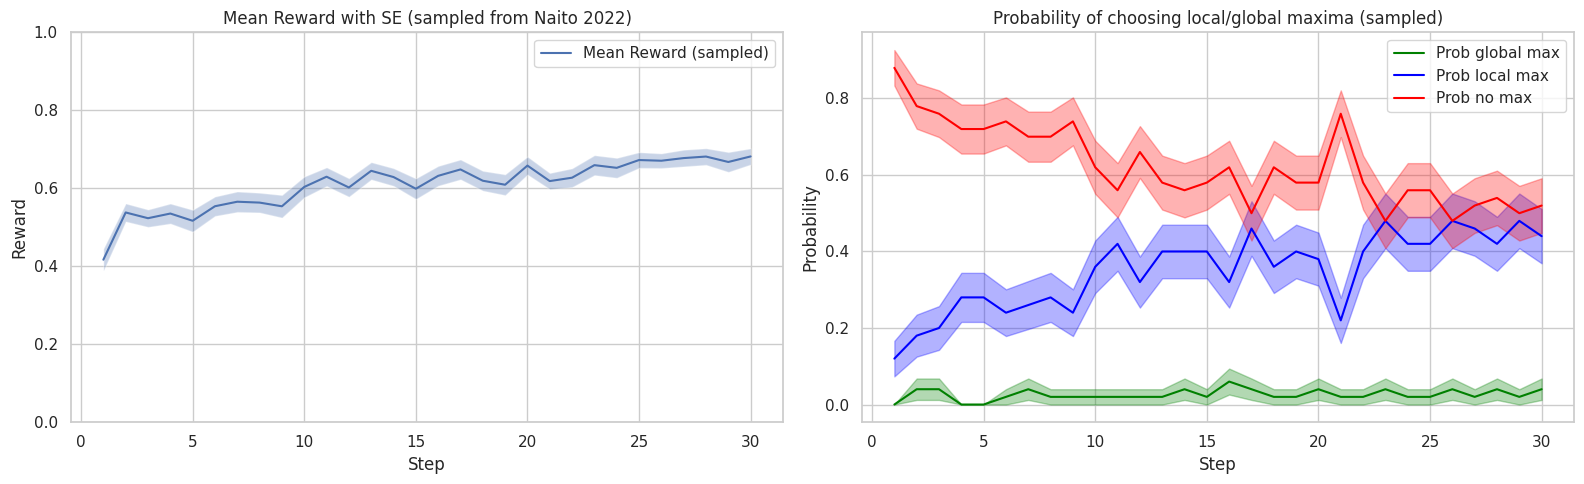

In [ ]:
# Visualize results from sampled parameters
df_grouped = sampled_df.groupby('Step').agg({
    'reward': ['mean', 'std'],
    'global_max': ['mean', 'std'],
    'local_max': ['mean', 'std'],
    'no_max': ['mean', 'std']
}).reset_index()

# Plot mean reward and probabilities in adjacent subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: mean reward with std
reward_mean = df_grouped['reward']['mean']
reward_SE = df_grouped['reward']['std'] / np.sqrt(n_runs) 
axes[0].plot(df_grouped['Step'], reward_mean, label='Mean Reward (sampled)')
axes[0].fill_between(df_grouped['Step'], reward_mean - reward_SE, reward_mean + reward_SE, alpha=0.3)
axes[0].set_title('Mean Reward with SE (sampled from Naito 2022)')
axes[0].set_xlabel('Step')
axes[0].set_ylabel('Reward')
axes[0].set_ylim(0, 1)
axes[0].legend()

# Right: probabilities
global_max_mean = df_grouped['global_max']['mean']
global_max_SE = df_grouped['global_max']['std'] / np.sqrt(n_runs)
local_max_mean = df_grouped['local_max']['mean']
local_max_SE = df_grouped['local_max']['std'] / np.sqrt(n_runs)
axes[1].plot(df_grouped['Step'], global_max_mean, label='Prob global max', color='green')
axes[1].fill_between(df_grouped['Step'], global_max_mean - global_max_SE, global_max_mean + global_max_SE, alpha=0.3, color='green')
axes[1].plot(df_grouped['Step'], local_max_mean, label='Prob local max', color='blue')
axes[1].fill_between(df_grouped['Step'], local_max_mean - local_max_SE, local_max_mean + local_max_SE, alpha=0.3, color='blue')
not_any_max_mean = df_grouped['no_max']['mean']
not_any_max_SE = df_grouped['no_max']['std'] / np.sqrt(n_runs)
axes[1].plot(df_grouped['Step'], not_any_max_mean, label='Prob no max', color='red')
axes[1].fill_between(df_grouped['Step'], not_any_max_mean - not_any_max_SE, not_any_max_mean + not_any_max_SE, alpha=0.3, color='red')
axes[1].set_title('Probability of choosing local/global maxima (sampled)')
axes[1].set_xlabel('Step')
axes[1].set_ylabel('Probability')
axes[1].legend()

plt.tight_layout()
plt.show()